# Baseline models

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import xgboost as xgb
import joblib

In [17]:
df = pd.read_csv('../data/clean/full_data.csv')

In [18]:
df.drop(columns = ["rr"], inplace = True)
df.drop(columns = ["clasi_rr"], inplace = True)
df.drop(columns = ["tmax_mean"], inplace = True)
df.drop(columns = ["tmin_mean"], inplace = True)
df.drop(columns = ["temp_prom"], inplace = True)
df.drop(columns = ["precip_total"], inplace = True)
df.drop(columns = ["precip_max"], inplace = True)
df.drop(columns = ["precip_min"], inplace = True)
df.drop(columns = ["precip_median"], inplace = True)
df.drop(columns = ["precip_mean"], inplace = True)
df.drop(columns = ["ndvi"], inplace = True)

In [19]:
df.drop(columns = ["rr_lag_1"], inplace = True)
df.drop(columns = ["clasi_rr_lag_1"], inplace = True)
df.drop(columns = ["rr_lag_2"], inplace = True)
df.drop(columns = ["clasi_rr_lag_2"], inplace = True)
df.drop(columns = ["rr_lag_3"], inplace = True)
df.drop(columns = ["clasi_rr_lag_3"], inplace = True)
df.drop(columns = ["rr_lag_4"], inplace = True)
df.drop(columns = ["clasi_rr_lag_4"], inplace = True)
df.drop(columns = ["rr_lag_5"], inplace = True)
df.drop(columns = ["clasi_rr_lag_5"], inplace = True)
df.drop(columns = ["rr_lag_6"], inplace = True)
df.drop(columns = ["clasi_rr_lag_6"], inplace = True)
df.drop(columns = ["rr_lag_7"], inplace = True)
df.drop(columns = ["clasi_rr_lag_7"], inplace = True)
df.drop(columns = ["rr_lag_8"], inplace = True)
df.drop(columns = ["clasi_rr_lag_8"], inplace = True)

In [20]:
df.head()

,casos,week_canton,urb,nino34ssta,casos_lag_8,casos_lag_7,casos_lag_6,casos_lag_5,casos_lag_4,casos_lag_3,...,precip_median_lag_2,precip_median_lag_1,precip_min_lag_8,precip_min_lag_7,precip_min_lag_6,precip_min_lag_5,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1
0,4,2020-9-101,1,0.392222,3,11,15,7,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2020-10-101,1,0.411116,11,15,7,0,2,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2020-11-101,1,0.453418,15,7,0,2,5,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,2020-12-101,1,0.474281,7,0,2,5,3,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,2020-13-101,1,0.449209,0,2,5,3,4,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
df.shape

(24928, 92)

In [22]:
df = pd.get_dummies(df, columns = ["urb"])

In [23]:
df.head()

,casos,week_canton,nino34ssta,casos_lag_8,casos_lag_7,casos_lag_6,casos_lag_5,casos_lag_4,casos_lag_3,casos_lag_2,...,precip_min_lag_7,precip_min_lag_6,precip_min_lag_5,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1,urb_0,urb_1,urb_2
0,4,2020-9-101,0.392222,3,11,15,7,0,2,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
1,2,2020-10-101,0.411116,11,15,7,0,2,5,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
2,2,2020-11-101,0.453418,15,7,0,2,5,3,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
3,0,2020-12-101,0.474281,7,0,2,5,3,4,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
4,0,2020-13-101,0.449209,0,2,5,3,4,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False


In [24]:
train = df[df['week_canton'] < '2024-1-101']
val = df[(df['week_canton'] >= '2024-1-101') & (df['week_canton'] < '2025-1-101')]
test = df[df['week_canton'] >= '2025-1-101']

X_train = train.drop(columns = ["casos", "week_canton"])
y_train = train['casos']

X_val = val.drop(columns = ["casos", "week_canton"])
y_val= val['casos']

X_test= test.drop(columns = ["casos", "week_canton"])
y_test = test['casos']

In [25]:
scaler = StandardScaler()  

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)  
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [26]:
X_test_for_reg = pd.concat([X_val, X_test], axis=0)
y_test_for_reg = pd.concat([y_val, y_test], axis=0)

X_test_for_reg_scaled = pd.DataFrame(scaler.transform(X_test_for_reg), columns=X_test_for_reg.columns)

In [27]:
train.shape, val.shape, test.shape

((16400, 94), (4264, 94), (4264, 94))

## Case number
### Linear regression

In [21]:
reg = LinearRegression().fit(X_train_scaled, y_train)

y_pred_reg = reg.predict(X_test_for_reg_scaled)

In [ ]:
r2_reg = r2_score(y_test_for_reg, y_pred_reg)
mae_reg = mean_absolute_error(y_test_for_reg, y_pred_reg)
rmse_reg = root_mean_squared_error(y_test_for_reg, y_pred_reg)

In [ ]:
print(f"""R2 reg: {round(r2_reg, 3)}
MAE reg: {round(mae_reg, 3)}
RMSE reg: {round(rmse_reg, 3)}
      """)

R2 reg: 0.892
MAE reg: 1.91
MSE reg: 23.263
RMSE reg: 4.823
      


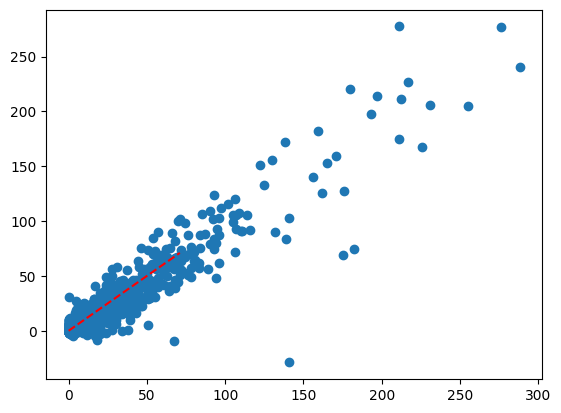

In [24]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_reg)

In [25]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": reg.coef_})
sd = pd.DataFrame({"Feature": X_train.columns, "Std": X_train_scaled.std()})
coef_df = coef_df.merge(sd, on = "Feature")
coef_df["Coefficient_std"] = coef_df["Coefficient"] * coef_df["Std"]
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=False)

coef_reg_sorted

,Feature,Coefficient,Std,Coefficient_std
8,casos_lag_1,9.362152,1.00003,9.362438
34,nino34ssta_lag_7,4.922276,1.00003,4.922427
38,nino34ssta_lag_3,4.627038,1.00003,4.627179
0,nino34ssta,4.292230,1.00003,4.292361
7,casos_lag_2,2.977402,1.00003,2.977493
...,...,...,...,...
37,nino34ssta_lag_4,-1.661382,1.00003,-1.661432
35,nino34ssta_lag_6,-1.969482,1.00003,-1.969542
33,nino34ssta_lag_8,-2.043687,1.00003,-2.043749
36,nino34ssta_lag_5,-2.243457,1.00003,-2.243525


Text(0.5, 0, 'Coefficient')

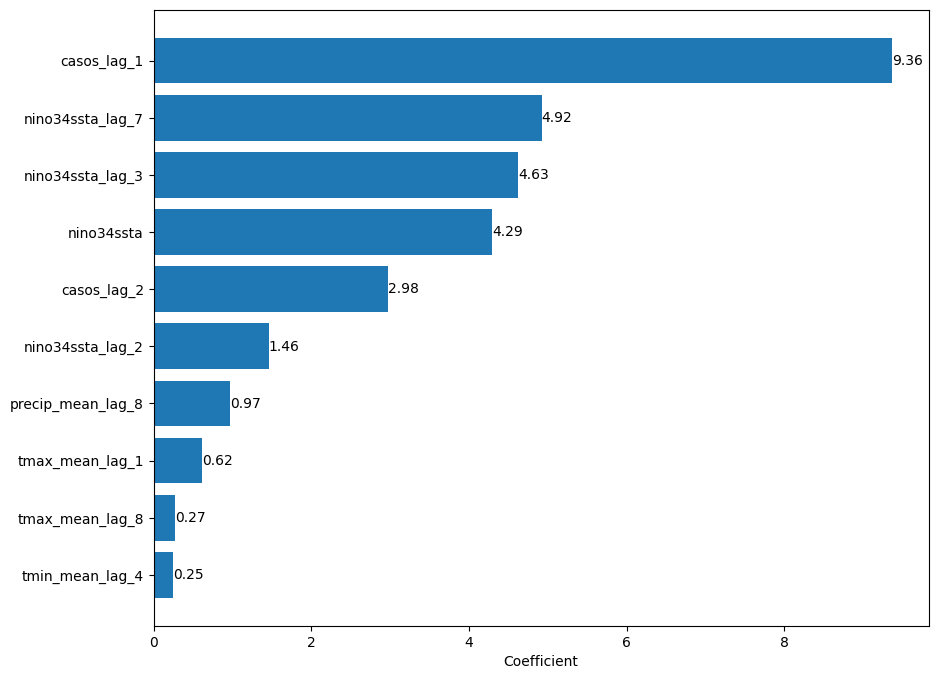

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=True)
ax.barh(coef_reg_sorted["Feature"].tail(10), coef_reg_sorted["Coefficient_std"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Coefficient")

### Random forest

In [ ]:
rf = RandomForestRegressor(oob_score=True)

# 2. Define search space
param_grid_rf = {
    'max_depth': [5, 6, 7, 8],
    'min_samples_split': [10, 100, 500],
    'ccp_alpha': [0, 1 /  10**5, 1 / 10**4, 1 / 10**3, 0.01, 0.1, 1, 10], 
    "criterion": ["squared_error", "absolute_error"]
}

# 3. Initialize and run Grid Search
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv = 5, n_jobs=-1, verbose=10)
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


KeyboardInterrupt: 

In [ ]:
joblib.dump(grid_rf, "../models/cases_rf.pkl")

In [ ]:
y_pred_rf = grid_rf.predict(X_test_scaled)

In [ ]:
mae_rf = mean_absolute_error(y_test_for_reg, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test_for_reg, y_pred_rf)

In [ ]:
print(f"""MAE rf: {round(mae_rf, 3)}
RMSE rf: {round(rmse_rf, 3)}
      """)

MAE rf: 1.958
RMSE rf: 5.294
      


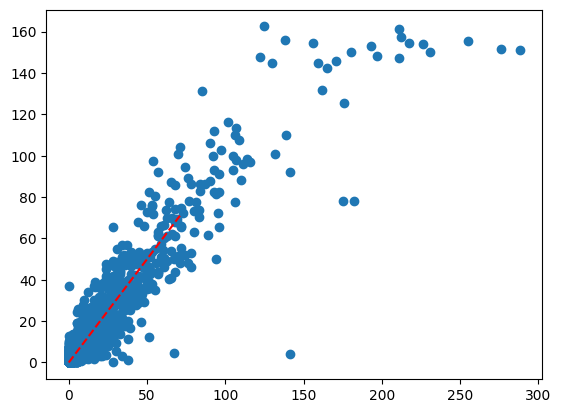

In [49]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_rf)

In [ ]:
imp_rf_df = pd.DataFrame({"Feature": X_train.columns, "Importance": grid_rf.best_estimator_.feature_importances_})
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=False)

imp_rf_sorted

,Feature,Importance
9,casos_lag_1,0.892334
8,casos_lag_2,0.010328
65,precip_max_lag_1,0.002801
7,casos_lag_3,0.002710
80,precip_median_lag_2,0.002374
...,...,...
83,precip_min_lag_7,0.000167
85,precip_min_lag_5,0.000143
87,precip_min_lag_3,0.000116
89,precip_min_lag_1,0.000107


Text(0.5, 0, 'Importance')

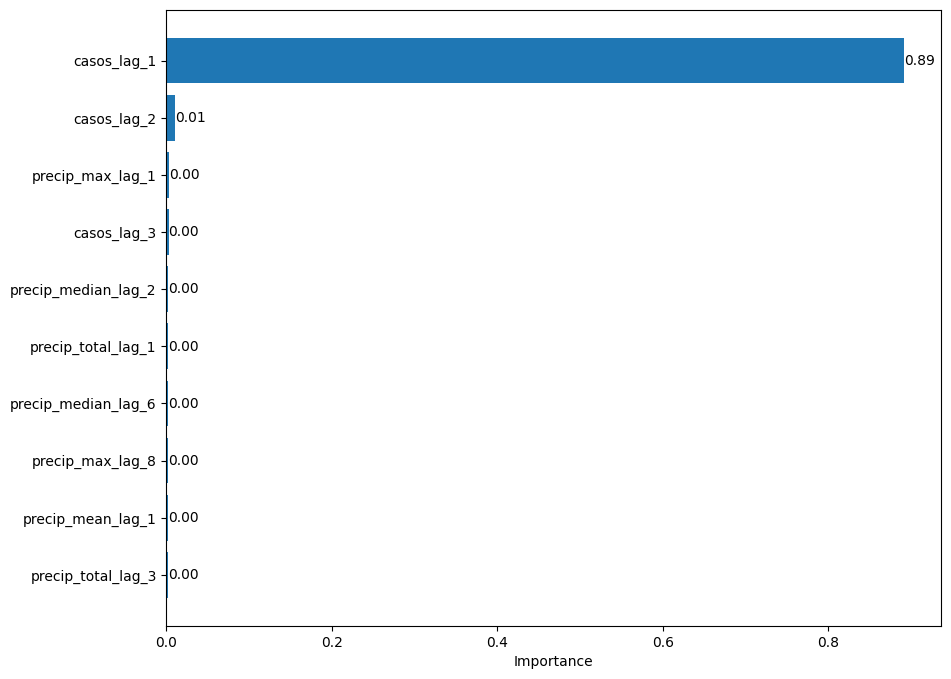

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_rf_sorted["Feature"].tail(10), imp_rf_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")

# XGBoost

In [ ]:
xgb = XGBRegressor()

# 2. Define search space
param_grid_xgb = {
    'max_depth': [5, 6, 7, 8],
    'learning_rate': [0.1, 0.3, 0.05],
    'n_estimator': [50, 100, 150], 
    "criterion": ["friednman_mse", "squared_error"]
}

# 3. Initialize and run Grid Search
grid_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb, cv = 5, n_jobs=-1, verbose=0)
grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:44:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "criterion", "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['friednman_mse'], 'learning_rate': [0.1], 'max_depth': [5], 'n_estimator': [50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [ ]:
joblib.dump(grid_xgb, "../models/cases_xgb.pkl")

In [30]:
y_pred_xgb = grid_xgb.predict(X_test_for_reg)

In [31]:
mae_xgb = mean_absolute_error(y_test_for_reg, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test_for_reg, y_pred_xgb)

In [32]:
print(f"""MAE xgb: {round(mae_xgb, 3)}
RMSE xgb: {round(rmse_xgb, 3)}
      """)

MAE xgb: 1.941
RMSE xgb: 5.532
      


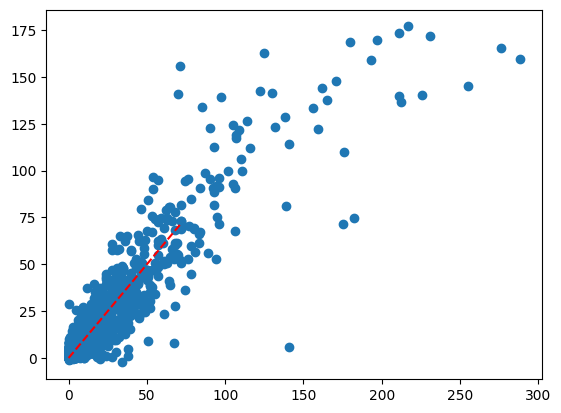

In [33]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_xgb)

In [37]:
imp_xgb_df = pd.DataFrame({"Feature": X_train.columns, "Importance": grid_xgb.best_estimator_.feature_importances_})
imp_xgb_sorted = imp_xgb_df.sort_values(by = "Importance", ascending=False)

imp_xgb_sorted

,Feature,Importance
8,casos_lag_1,0.499059
7,casos_lag_2,0.031586
36,nino34ssta_lag_5,0.025385
48,temp_prom_lag_1,0.023835
79,precip_median_lag_2,0.018229
...,...,...
71,precip_mean_lag_2,0.000000
68,precip_mean_lag_5,0.000000
67,precip_mean_lag_6,0.000000
90,urb_1,0.000000


Text(0.5, 0, 'Importance')

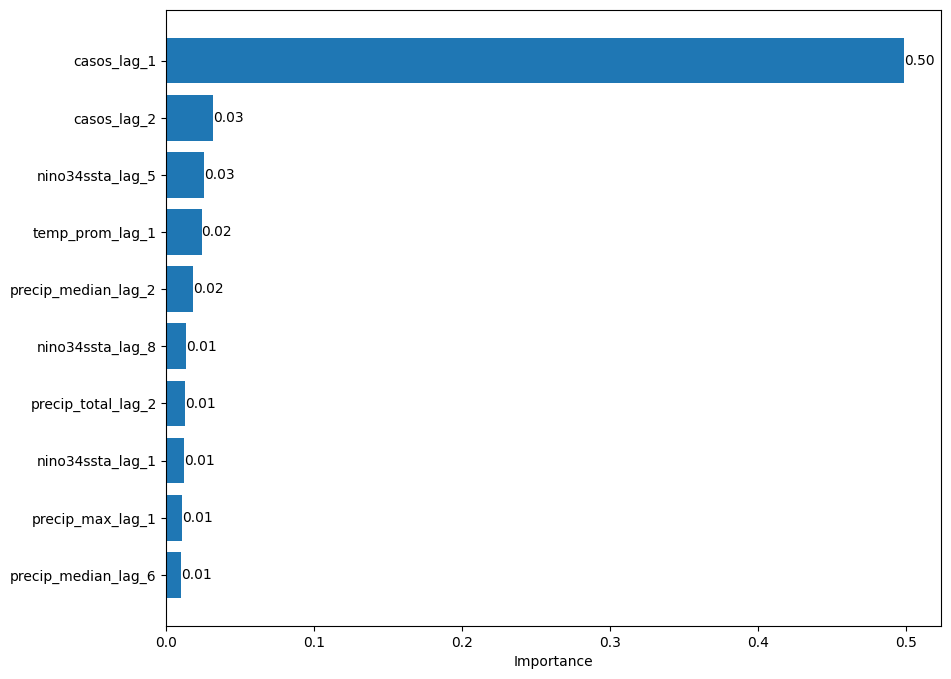

In [38]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_xgb_sorted = imp_xgb_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_xgb_sorted["Feature"].tail(10), imp_xgb_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")

In [ ]:
# REMEMBER TO RUN THE CODE WITHOUT URB DUMMIES

In [ ]:
# dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
# dval = xgb.DMatrix(X_val, y_val, enable_categorical=True)
# dtest = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [ ]:
# params = {"objective": "reg:squarederror", "tree_method": "hist"}

In [ ]:
# n = 100
# xgb_model = xgb.train(
#    params=params,
#    dtrain=dtrain,
#    num_boost_round=n,
#    evals=[(dtrain, "train"), (dval, "validation")],
#    verbose_eval=10, 
#    early_stopping_rounds=50
# )

[0]	train-rmse:8.69233	validation-rmse:16.16330
[10]	train-rmse:2.07493	validation-rmse:7.38947
[20]	train-rmse:1.64864	validation-rmse:7.35595
[30]	train-rmse:1.47897	validation-rmse:7.36674
[40]	train-rmse:1.31049	validation-rmse:7.37893
[50]	train-rmse:1.17725	validation-rmse:7.40714
[60]	train-rmse:1.06826	validation-rmse:7.43075
[70]	train-rmse:0.98502	validation-rmse:7.43122
[72]	train-rmse:0.96575	validation-rmse:7.43952


In [ ]:
# xgb_preds = xgb_model.predict(dtest)

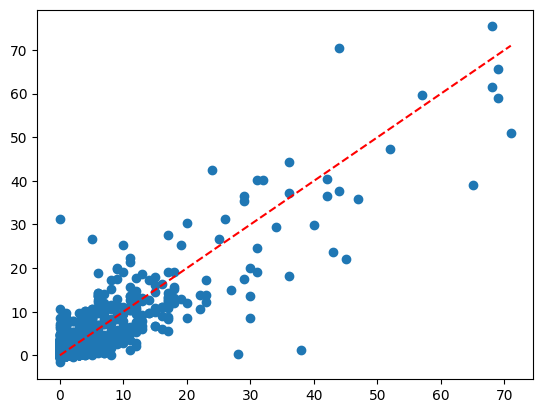

In [ ]:
# fig, ax = plt.subplots()
# ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
# ax.scatter(y_test, xgb_preds)

In [ ]:
# mae_xgb = mean_absolute_error(y_test, xgb_preds)
# rmse_xgb = root_mean_squared_error(y_test, xgb_preds)

# print(f"""MAE xgb: {round(mae_xgb, 3)}
# RMSE xgb: {round(rmse_xgb, 3)}
#       """)

MAE xgb: 0.963
RMSE xgb: 2.157
      


In [ ]:
# importance_xgb = xgb_model.get_score(importance_type="weight")
# importance_xgb_df = pd.DataFrame({"Feature": list(importance_xgb.keys()), "Importance": list(importance_xgb.values())})
# importance_xgb_sorted = importance_xgb_df.sort_values(by = "Importance", ascending=False) 
# importance_xgb_sorted.head(10)

,Feature,Importance
9,casos_lag_1,251.0
8,casos_lag_2,178.0
1,nino34ssta,169.0
2,casos_lag_8,142.0
6,casos_lag_4,131.0
7,casos_lag_3,123.0
3,casos_lag_7,117.0
5,casos_lag_5,117.0
4,casos_lag_6,105.0
0,urb,81.0


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

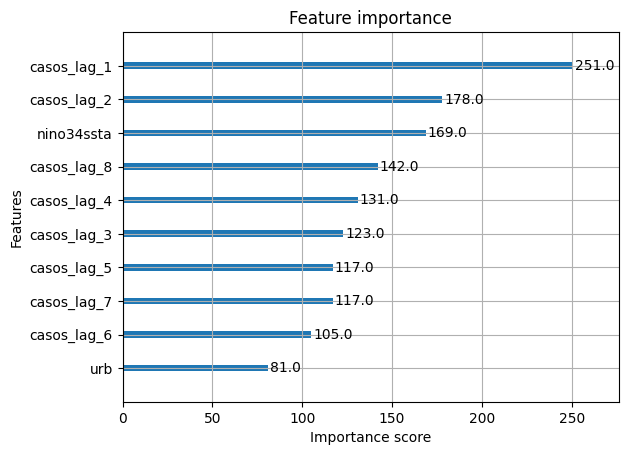

In [ ]:
# xgb.plot_importance(xgb_model, max_num_features=10, importance_type="weight")